# PINNs pour l'équation de Schrödinger
## Électron dans un puits quantique GaAs/AlGaAs

**Système physique** : puits quantique GaAs de 10 nm  
**Problème direct** : résoudre l'équation de Schrödinger dépendante du temps  
**Problème inverse** : retrouver la masse effective $m^*$ à partir de mesures de $|\psi|^2$  
**Incertitude** : MC Dropout et Deep Ensembles

---

## 1. Imports et configuration

In [112]:
import torch
from torch.autograd import Variable
import torch.nn as nn
import numpy as np
from numpy import trapezoid
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import copy
import warnings
warnings.filterwarnings('ignore')

print("MPS disponible :", torch.mps.is_available())
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Device :", device)
torch.manual_seed(42)
np.random.seed(42)

MPS disponible : True
Device : mps


## 2. Constantes physiques et adimensionnement

### Système réel : électron dans un puits quantique GaAs/AlGaAs

On considère un puits de potentiel infini de largeur $L = 10\,\text{nm}$ dans du GaAs.
La masse effective de l'électron dans GaAs est $m^* = 0.067\,m_e$.

### Adimensionnement

On définit les échelles caractéristiques :
- $x_0 = L$ (longueur)  
- $E_0 = \hbar^2 / (m^* L^2)$ (énergie)  
- $t_0 = \hbar / E_0$ (temps)  

L'équation de Schrödinger $i\hbar\partial_t\psi = -\frac{\hbar^2}{2m^*}\partial_{xx}\psi + V\psi$ devient :

$$i\frac{\partial\psi}{\partial\tilde{t}} = -\frac{1}{2}\frac{\partial^2\psi}{\partial\tilde{x}^2} + \tilde{V}\psi$$

In [113]:
# --- Constantes physiques SI ---
hbar = 1.0546e-34    # J·s
m_e  = 9.109e-31     # kg
m_star = 0.067 * m_e # masse effective GaAs (kg)
L    = 10e-9          # largeur du puits (m)
eV   = 1.602e-19      # J/eV

# --- Échelles d'adimensionnement ---
E_0 = hbar**2 / (m_star * L**2)       # échelle d'énergie (J)
t_0 = hbar / E_0                       # échelle de temps (s)
x_0 = L                                # échelle de longueur (m)

E_0_meV = E_0 / eV * 1000
t_0_fs  = t_0 * 1e15
x_0_nm  = x_0 * 1e9


# On a fait un jolie print qui résume les données
print("="*60)
print("CONSTANTES PHYSIQUES DU PUITS QUANTIQUE GaAs")
print("="*60)
print(f"Largeur du puits      : L   = {x_0_nm:.1f} nm")
print(f"Masse effective       : m*  = {m_star/m_e:.3f} m_e = {m_star:.3e} kg")
print(f"Échelle d'énergie     : E_0 = {E_0_meV:.2f} meV")
print(f"Échelle de temps      : t_0 = {t_0_fs:.1f} fs")
print()

# --- Niveaux d'énergie (en unités réduites et physiques) ---
for n in range(1, 5):
    E_n_red = n**2 * np.pi**2 / 2  # unités réduites
    E_n_meV = E_n_red * E_0_meV    # meV
    print(f"E_{n} = {E_n_red:.3f} (réd.) = {E_n_meV:.1f} meV")

# Fréquence de battement entre n=1 et n=2
omega_21 = 3 * np.pi**2 / 2  # unités réduites
f_21_THz = omega_21 / (2 * np.pi * t_0) * 1e-12
T_beat_red = 2 * np.pi / omega_21
T_beat_fs = T_beat_red * t_0_fs
print(f"\nBattement 2-1 : ω₂₁ = {omega_21:.3f} (réd.)")
print(f"Période        : T_beat = {T_beat_red:.4f} (réd.) = {T_beat_fs:.1f} fs")
print(f"Fréquence      : f₂₁ = {f_21_THz:.1f} THz (infrarouge moyen)")

CONSTANTES PHYSIQUES DU PUITS QUANTIQUE GaAs
Largeur du puits      : L   = 10.0 nm
Masse effective       : m*  = 0.067 m_e = 6.103e-32 kg
Échelle d'énergie     : E_0 = 11.38 meV
Échelle de temps      : t_0 = 57.9 fs

E_1 = 4.935 (réd.) = 56.1 meV
E_2 = 19.739 (réd.) = 224.5 meV
E_3 = 44.413 (réd.) = 505.2 meV
E_4 = 78.957 (réd.) = 898.2 meV

Battement 2-1 : ω₂₁ = 14.804 (réd.)
Période        : T_beat = 0.4244 (réd.) = 24.6 fs
Fréquence      : f₂₁ = 40.7 THz (infrarouge moyen)


## 3. Solution analytique exacte (vérité terrain)

Pour le puits infini avec CI $\psi(x,0) = \frac{1}{\sqrt{2}}[\phi_1(x) + \phi_2(x)]$ :

$$\psi(x,t) = \frac{1}{\sqrt{2}}\left[\phi_1(x)\,e^{-iE_1 t} + \phi_2(x)\,e^{-iE_2 t}\right]$$

avec $\phi_n(x) = \sqrt{2}\sin(n\pi x)$ et $E_n = n^2\pi^2/2$.

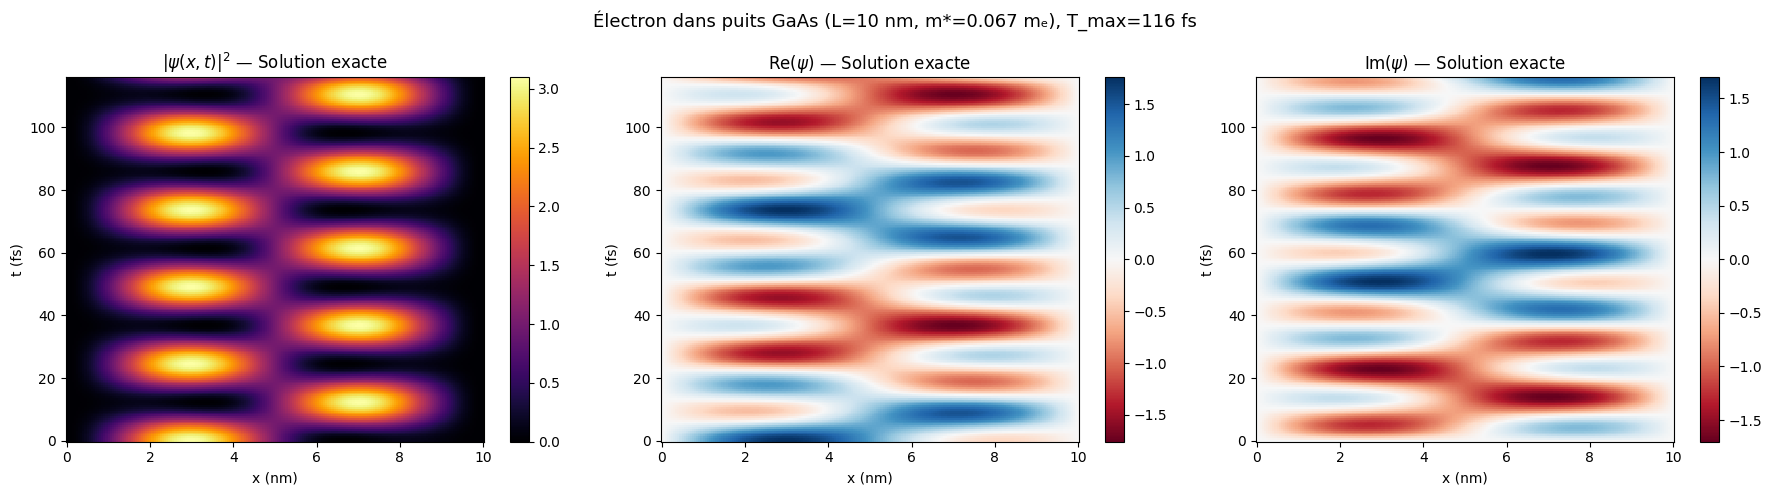

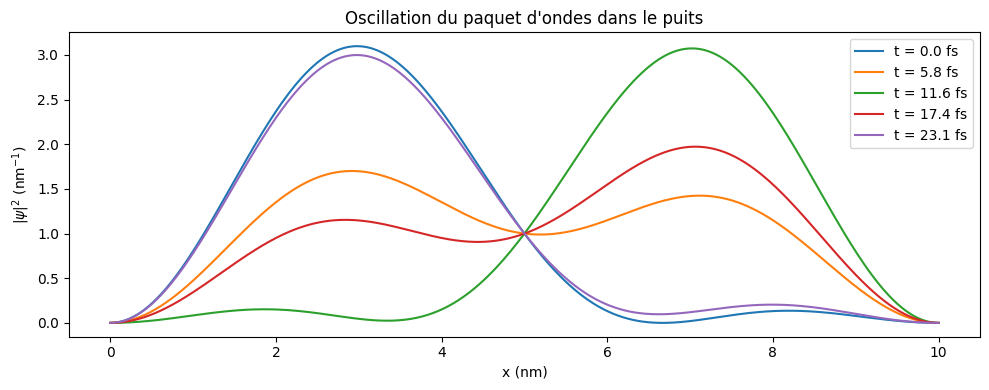

t = 0.0 (réd.) = 0.0 fs : ||psi||² = 1.000000
t = 0.5 (réd.) = 28.9 fs : ||psi||² = 1.000000
t = 1.0 (réd.) = 57.9 fs : ||psi||² = 1.000000
t = 1.5 (réd.) = 86.8 fs : ||psi||² = 1.000000
t = 2.0 (réd.) = 115.7 fs : ||psi||² = 1.000000


In [114]:
def psi_exact(x, t):
    """Solution analytique en coordonnées adimensionnées.
    x, t : arrays numpy
    Retourne : psi (complexe), de même shape que x
    """
    phi1 = np.sqrt(2) * np.sin(np.pi * x)
    phi2 = np.sqrt(2) * np.sin(2 * np.pi * x)
    E1 = np.pi**2 / 2
    E2 = 2 * np.pi**2
    psi = (1/np.sqrt(2)) * (phi1 * np.exp(-1j * E1 * t) + phi2 * np.exp(-1j * E2 * t))
    return psi

def psi_exact_components(x, t):
    """Retourne (Re(psi), Im(psi)) séparément."""
    psi = psi_exact(x, t)
    return psi.real, psi.imag

# --- Visualisation de la solution analytique ---
Nx, Nt = 200, 200
T_max = 2.0  # en unités réduites (~116 fs)

x_grid = np.linspace(0, 1, Nx)
t_grid = np.linspace(0, T_max, Nt)
X, T_grid = np.meshgrid(x_grid, t_grid)
PSI = psi_exact(X, T_grid)
RHO = np.abs(PSI)**2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# |psi|^2
im0 = axes[0].pcolormesh(X * x_0_nm, T_grid * t_0_fs, RHO, cmap='inferno', shading='auto')
axes[0].set_xlabel('x (nm)')
axes[0].set_ylabel('t (fs)')
axes[0].set_title(r'$|\psi(x,t)|^2$ — Solution exacte')
plt.colorbar(im0, ax=axes[0])

# Re(psi)
im1 = axes[1].pcolormesh(X * x_0_nm, T_grid * t_0_fs, PSI.real, cmap='RdBu', shading='auto')
axes[1].set_xlabel('x (nm)')
axes[1].set_ylabel('t (fs)')
axes[1].set_title(r'Re($\psi$) — Solution exacte')
plt.colorbar(im1, ax=axes[1])

# Im(psi)
im2 = axes[2].pcolormesh(X * x_0_nm, T_grid * t_0_fs, PSI.imag, cmap='RdBu', shading='auto')
axes[2].set_xlabel('x (nm)')
axes[2].set_ylabel('t (fs)')
axes[2].set_title(r'Im($\psi$) — Solution exacte')
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f'Électron dans puits GaAs (L={x_0_nm:.0f} nm, m*=0.067 mₑ), '
             f'T_max={T_max*t_0_fs:.0f} fs', fontsize=13)
plt.tight_layout()
plt.show()

# --- Coupe temporelle : oscillation du paquet d'ondes ---
fig, ax = plt.subplots(figsize=(10, 4))
x_plot = np.linspace(0, 1, 500)
for t_val in [0, 0.1, 0.2, 0.3, 0.4]:
    rho = np.abs(psi_exact(x_plot, t_val))**2
    ax.plot(x_plot * x_0_nm, rho, label=f't = {t_val*t_0_fs:.1f} fs')
ax.set_xlabel('x (nm)')
ax.set_ylabel(r'$|\psi|^2$ (nm$^{-1}$)')
ax.set_title('Oscillation du paquet d\'ondes dans le puits')
ax.legend()
plt.tight_layout()
plt.show()

# Vérification normalisation
for t_val in [0, 0.5, 1.0, 1.5, 2.0]:
    norm = np.trapezoid(np.abs(psi_exact(x_plot, t_val))**2, x_plot)
    print(f"t = {t_val:.1f} (réd.) = {t_val*t_0_fs:.1f} fs : ||psi||² = {norm:.6f}")

## 4. Définition du réseau de neurones

Le réseau prend $(\tilde{x}, \tilde{t})$ en entrée et sort $(u, v) = (\text{Re}\,\psi, \text{Im}\,\psi) \in \mathbb{R}^2$.

Architecture : 4 couches cachées de 64 neurones avec activation $\tanh$.

In [115]:
class SchrodingerNet(nn.Module):
    """Réseau feed-forward pour approximer psi(x,t).
    Sortie : (Re(psi), Im(psi)) de dimension 2.
    """
    def __init__(self, hidden_dim=64, n_hidden=4, dropout_rate=0.0):
        super().__init__()
        layers = [nn.Linear(2, hidden_dim), nn.Tanh()]
        for _ in range(n_hidden - 1):
            if dropout_rate > 0:
                layers.append(nn.Dropout(p=dropout_rate))
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, 2))  # sortie (u, v)
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

## 5. Définition du problème physique

Même structure que `forward_problem` du TP thermique : on définit les résidus de l'EDP, des CI et des CL.

**Résidus de l'EDP** (2 résidus couplés) :
- $r_{\text{Re}} = \partial_t u - \frac{\alpha}{2}\partial_{xx}v + Vv$
- $r_{\text{Im}} = \partial_t v + \frac{\alpha}{2}\partial_{xx}u - Vu$

Le paramètre $\alpha$ vaut 1 en problème direct. Pour le problème inverse, il devient apprenable.

In [116]:
class SchrodingerProblem:
    def __init__(self, net, alpha=1.0, alpha_trainable=False):
        self.net = net
        # alpha = 1 quand m* = m*_vrai. Pour le pb inverse, on l'apprend.
        if alpha_trainable:
            self.alpha = nn.Parameter(torch.tensor([alpha], dtype=torch.float32, device=device))
        else:
            self.alpha = torch.tensor([alpha], dtype=torch.float32, device=device)

    def ic_real(self, x):
        """Condition initiale : Re(psi(x, 0)) = (phi_1 + phi_2) / sqrt(2)"""
        phi1 = torch.sqrt(torch.tensor(2.0)) * torch.sin(np.pi * x)
        phi2 = torch.sqrt(torch.tensor(2.0)) * torch.sin(2 * np.pi * x)
        return (phi1 + phi2) / np.sqrt(2)

    def ic_imag(self, x):
        """Im(psi(x, 0)) = 0 (CI purement réelle)"""
        return torch.zeros_like(x)

    def residual(self, x, t):
        """Calcule les 2 résidus de l'EDP de Schrödinger.
        Exactement comme problem.f() dans le TP thermique, mais 2 résidus.
        """
        out = self.net(x, t)  # (N, 2)
        u = out[:, 0:1]  # Re(psi)
        v = out[:, 1:2]  # Im(psi)

        # Dérivées premières (comme u_x et u_t dans le TP)
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                                   retain_graph=True, create_graph=True)[0]
        v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v),
                                   retain_graph=True, create_graph=True)[0]
        u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                                   retain_graph=True, create_graph=True)[0]
        v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v),
                                   retain_graph=True, create_graph=True)[0]

        # Dérivées secondes (comme flux_x dans le TP)
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                    retain_graph=True, create_graph=True)[0]
        v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x),
                                    retain_graph=True, create_graph=True)[0]

        # V(x) = 0 dans le puits infini
        # Résidus de i d_t psi = -alpha/2 d_xx psi
        # Re: d_t u = +alpha/2 * d_xx v
        # Im: d_t v = -alpha/2 * d_xx u
        r_re = u_t - (self.alpha / 2) * v_xx
        r_im = v_t + (self.alpha / 2) * u_xx

        return r_re, r_im

    def f_ic(self, x, t):
        """Résidu de la condition initiale (comme dans le TP)."""
        out = self.net(x, t)
        u = out[:, 0:1]
        v = out[:, 1:2]
        r_u = u - self.ic_real(x)
        r_v = v - self.ic_imag(x)
        return r_u, r_v

    def f_bc(self, x, t):
        """Résidu des conditions aux limites psi(0,t) = psi(1,t) = 0."""
        out = self.net(x, t)
        u = out[:, 0:1]
        v = out[:, 1:2]
        return u, v  # doivent être ~0

## 6. Boucle d'entraînement

Même logique que `solve()` du TP thermique :
1. Tirer des points de collocation (intérieur, CI, CL)
2. Calculer les résidus
3. Minimiser la loss totale par Adam

In [117]:
def solve_schrodinger(problem, N_iter=5000, lr=1e-3, N_f=2000, N_ic=200, N_bc=200,
                      T_max=2.0, lambda_f=1.0, lambda_ic=10.0, lambda_bc=10.0,
                      verbose=True, data_points=None, lambda_data=1.0):
    """
    Entraîne le PINN. Compatible problème direct ET inverse.
    
    data_points : dict {'x': tensor, 't': tensor, 'rho': tensor} pour le pb inverse
    """
    net = problem.net
    params = list(net.parameters())

    # Si alpha est apprenable (pb inverse), l'ajouter aux paramètres
    if isinstance(problem.alpha, nn.Parameter):
        params.append(problem.alpha)

    optimizer = torch.optim.Adam(params, lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)
    mse = nn.MSELoss()

    history = {'loss': [], 'loss_f': [], 'loss_ic': [], 'loss_bc': [], 'alpha': []}

    for epoch in range(N_iter):
        optimizer.zero_grad()

        # --- Points de collocation intérieurs (re-tirés à chaque époque, comme le TP) ---
        x_f = torch.rand(N_f, 1, requires_grad=True, device=device)
        t_f = torch.rand(N_f, 1, requires_grad=True, device=device) * T_max

        # --- Résidu EDP ---
        r_re, r_im = problem.residual(x_f, t_f)
        zeros_f = torch.zeros_like(r_re)
        loss_f = mse(r_re, zeros_f) + mse(r_im, zeros_f)

        # --- Condition initiale (t=0) ---
        x_ic = torch.rand(N_ic, 1, requires_grad=True, device=device)
        t_ic = torch.zeros(N_ic, 1, requires_grad=True, device=device)
        r_ic_u, r_ic_v = problem.f_ic(x_ic, t_ic)
        zeros_ic = torch.zeros_like(r_ic_u)
        loss_ic = mse(r_ic_u, zeros_ic) + mse(r_ic_v, zeros_ic)

        # --- Conditions aux limites (x=0 et x=1) ---
        N_bc_half = N_bc // 2
        x_bc = torch.cat([torch.zeros(N_bc_half, 1), torch.ones(N_bc_half, 1)], dim=0).to(device)
        x_bc.requires_grad_(True)
        t_bc = (torch.rand(N_bc, 1, device=device) * T_max).requires_grad_(True)
        r_bc_u, r_bc_v = problem.f_bc(x_bc, t_bc)
        zeros_bc = torch.zeros_like(r_bc_u)
        loss_bc = mse(r_bc_u, zeros_bc) + mse(r_bc_v, zeros_bc)

        # --- Loss totale ---
        loss = lambda_f * loss_f + lambda_ic * loss_ic + lambda_bc * loss_bc

        # --- Données capteurs (problème inverse) ---
        if data_points is not None:
            out_data = problem.net(data_points['x'], data_points['t'])
            u_d = out_data[:, 0:1]
            v_d = out_data[:, 1:2]
            rho_pred = u_d**2 + v_d**2
            loss_data = mse(rho_pred, data_points['rho'])
            loss = loss + lambda_data * loss_data

        loss.backward()
        optimizer.step()
        scheduler.step()

        # --- Logging ---
        history['loss'].append(loss.item())
        history['loss_f'].append(loss_f.item())
        history['loss_ic'].append(loss_ic.item())
        history['loss_bc'].append(loss_bc.item())
        if isinstance(problem.alpha, nn.Parameter):
            history['alpha'].append(problem.alpha.item())

        if verbose and (epoch <= 10 or epoch % 500 == 0 or epoch == N_iter - 1):
            msg = f"Epoch {epoch:5d} | Loss: {loss.item():.2e} | EDP: {loss_f.item():.2e} | IC: {loss_ic.item():.2e} | BC: {loss_bc.item():.2e}"
            if isinstance(problem.alpha, nn.Parameter):
                msg += f" | α: {problem.alpha.item():.4f}"
            print(msg)

    return history

## 7. Fonctions de visualisation

In [118]:
def evaluate_pinn(net, Nx=200, Nt=200, T_max=2.0):
    """Évalue le PINN sur une grille et retourne les arrays numpy."""
    x_g = np.linspace(0, 1, Nx)
    t_g = np.linspace(0, T_max, Nt)
    X, T = np.meshgrid(x_g, t_g)
    x_flat = torch.tensor(X.ravel(), dtype=torch.float32, device=device).reshape(-1, 1)
    t_flat = torch.tensor(T.ravel(), dtype=torch.float32, device=device).reshape(-1, 1)

    net.eval()
    with torch.no_grad():
        out = net(x_flat, t_flat)
        u_pred = out[:, 0].cpu().numpy().reshape(X.shape)
        v_pred = out[:, 1].cpu().numpy().reshape(X.shape)
    net.train()
    return X, T, u_pred, v_pred

def plot_comparison(net, T_max=2.0, title_prefix=""):
    """Compare PINN vs solution analytique."""
    X, T, u_pred, v_pred = evaluate_pinn(net, T_max=T_max)
    rho_pred = u_pred**2 + v_pred**2

    psi_ex = psi_exact(X, T)
    rho_exact = np.abs(psi_ex)**2

    error_rho = np.abs(rho_pred - rho_exact)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].pcolormesh(X * x_0_nm, T * t_0_fs, rho_exact, cmap='inferno', shading='auto')
    axes[0].set_title(r'$|\psi|^2$ exact')
    axes[0].set_xlabel('x (nm)'); axes[0].set_ylabel('t (fs)')
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].pcolormesh(X * x_0_nm, T * t_0_fs, rho_pred, cmap='inferno', shading='auto')
    axes[1].set_title(r'$|\psi|^2$ PINN')
    axes[1].set_xlabel('x (nm)'); axes[1].set_ylabel('t (fs)')
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].pcolormesh(X * x_0_nm, T * t_0_fs, error_rho, cmap='hot', shading='auto')
    axes[2].set_title(rf'Erreur $|\Delta\rho|$ (max={error_rho.max():.4f})')
    axes[2].set_xlabel('x (nm)'); axes[2].set_ylabel('t (fs)')
    plt.colorbar(im2, ax=axes[2])

    plt.suptitle(f'{title_prefix}Comparaison PINN vs analytique (GaAs, L={x_0_nm:.0f}nm)', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Erreur L2 relative
    psi_pred_complex = u_pred + 1j * v_pred
    err_L2 = np.sqrt(np.sum(np.abs(psi_pred_complex - psi_ex)**2)) / np.sqrt(np.sum(np.abs(psi_ex)**2))
    err_rho_mean = np.mean(error_rho)
    print(f"Erreur L² relative sur ψ : {err_L2:.4e}")
    print(f"Erreur moyenne sur |ψ|²  : {err_rho_mean:.4e}")

    # Conservation de la norme
    x_1d = np.linspace(0, 1, 200)
    t_vals = np.linspace(0, T_max, 50)
    norms = []
    for tv in t_vals:
        xt = torch.tensor(x_1d, dtype=torch.float32, device=device).reshape(-1, 1)
        tt = torch.full_like(xt, tv)
        with torch.no_grad():
            out = net(xt, tt)
        rho_line = (out[:, 0]**2 + out[:, 1]**2).cpu().numpy()
        norms.append(np.trapezoid(rho_line, x_1d))

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(np.array(t_vals) * t_0_fs, norms, 'b-o', markersize=3)
    ax.axhline(1.0, color='r', linestyle='--', label='Norme exacte = 1')
    ax.set_xlabel('t (fs)')
    ax.set_ylabel(r'$\int|\psi|^2 dx$')
    ax.set_title('Conservation de la norme')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return err_L2

## 8. Problème direct : résolution de l'équation de Schrödinger

On résout l'EDP avec $\alpha = 1$ (soit $m^* = 0.067\,m_e$) et on compare à la vérité terrain analytique.

In [ ]:
# --- Entraînement du problème direct ---
T_MAX = 2.0  # unités réduites ~ 116 fs

net_forward = SchrodingerNet(hidden_dim=64, n_hidden=4, dropout_rate=0.0).to(device)
problem_forward = SchrodingerProblem(net_forward, alpha=1.0, alpha_trainable=False)

print(f"Domaine : x ∈ [0, {x_0_nm:.0f}] nm,  t ∈ [0, {T_MAX*t_0_fs:.0f}] fs")
print(f"Nombre de paramètres : {sum(p.numel() for p in net_forward.parameters())}")
print()

history_fwd = solve_schrodinger(
    problem_forward,
    N_iter=100000,
    lr=5e-3,
    N_f=2000,
    N_ic=200,
    N_bc=200,
    T_max=T_MAX,
    lambda_f=1.0,
    lambda_ic=20.0,
    lambda_bc=20.0
)

Domaine : x ∈ [0, 10] nm,  t ∈ [0, 116] fs
Nombre de paramètres : 12802



TypeError: solve_schrodinger() got an unexpected keyword argument 'pretrain_ic'

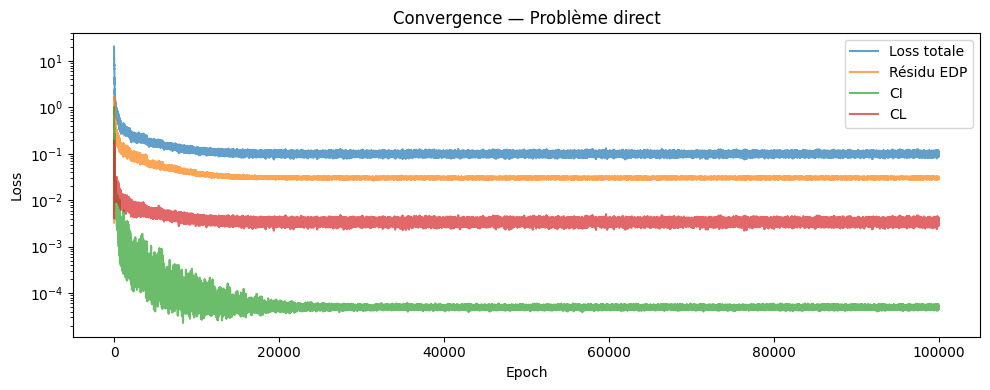

In [ ]:
# --- Courbe de convergence ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(history_fwd['loss'], label='Loss totale', alpha=0.7)
ax.semilogy(history_fwd['loss_f'], label='Résidu EDP', alpha=0.7)
ax.semilogy(history_fwd['loss_ic'], label='CI', alpha=0.7)
ax.semilogy(history_fwd['loss_bc'], label='CL', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Convergence — Problème direct')
ax.legend()
plt.tight_layout()
plt.show()

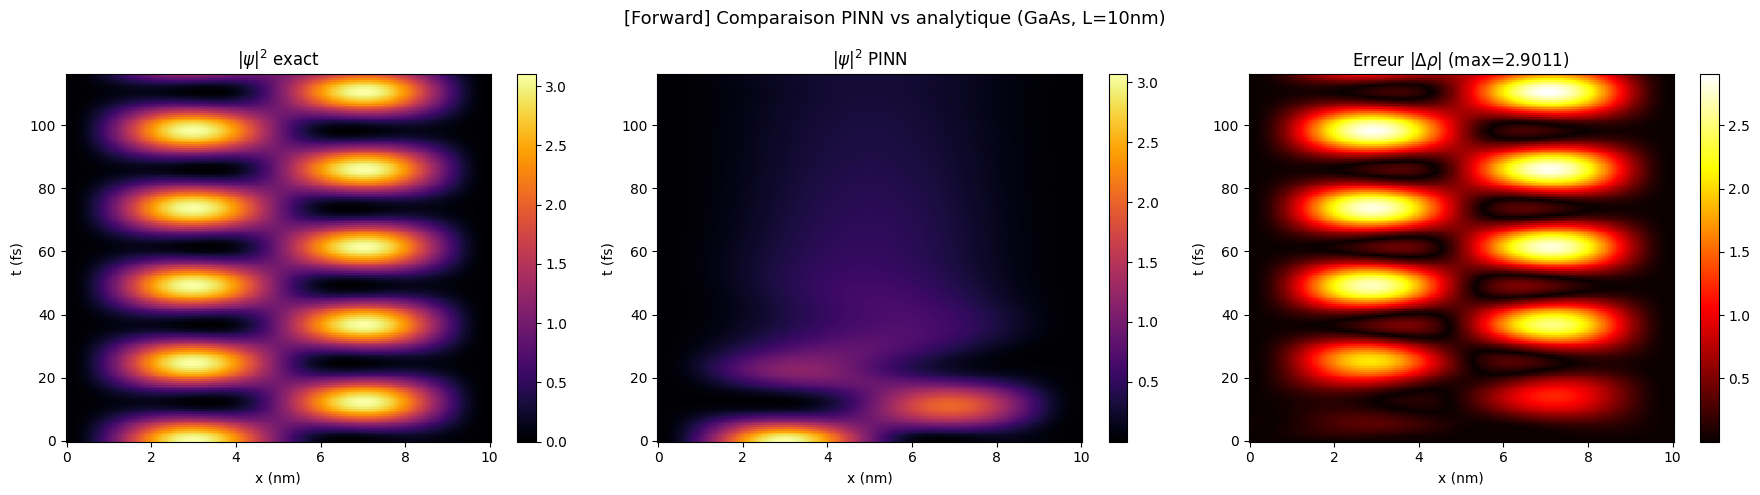

Erreur L² relative sur ψ : 1.1503e+00
Erreur moyenne sur |ψ|²  : 6.7714e-01


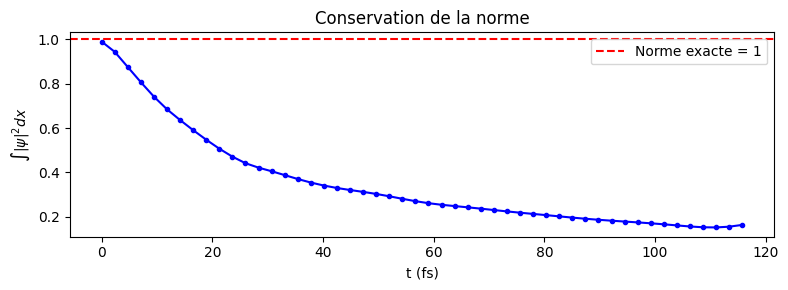

In [ ]:
# --- Comparaison PINN vs analytique ---
err_fwd = plot_comparison(net_forward, T_max=T_MAX, title_prefix="[Forward] ")

## 9. Problème inverse : retrouver la masse effective $m^*$

On génère des données synthétiques $|\psi_{\text{data}}|^2$ à partir de la solution exacte (avec bruit), puis on entraîne un PINN avec $\alpha$ comme paramètre apprenable.

Si le PINN retrouve $\hat{\alpha} \approx 1$, cela confirme que $m^* = 0.067\,m_e$.

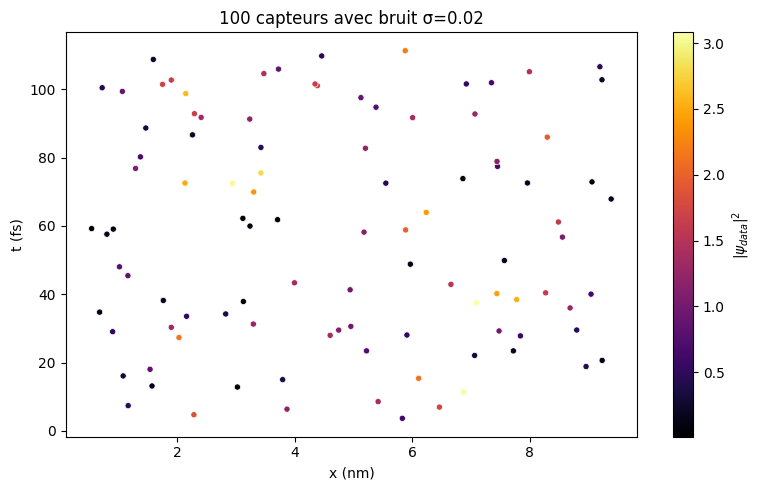

Données : 100 capteurs, bruit σ = 0.02
m*_vrai = 0.067 mₑ → α* = 1.0


In [ ]:
# --- Génération des données capteurs ---
N_data = 100  # nombre de points de mesure
sigma_noise = 0.02  # bruit sur |psi|^2

# Positions des capteurs (répartis dans le domaine)
x_data_np = np.random.uniform(0.05, 0.95, N_data)
t_data_np = np.random.uniform(0.05, T_MAX - 0.05, N_data)

# Densité de probabilité exacte + bruit
rho_data_np = np.abs(psi_exact(x_data_np, t_data_np))**2
rho_data_np += np.random.normal(0, sigma_noise, N_data)
rho_data_np = np.clip(rho_data_np, 0, None)  # densité >= 0

# Tenseurs pour le PINN
data_points = {
    'x': torch.tensor(x_data_np, dtype=torch.float32, device=device).reshape(-1, 1),
    't': torch.tensor(t_data_np, dtype=torch.float32, device=device).reshape(-1, 1),
    'rho': torch.tensor(rho_data_np, dtype=torch.float32, device=device).reshape(-1, 1)
}

# Visualisation des capteurs
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(x_data_np * x_0_nm, t_data_np * t_0_fs, c=rho_data_np, cmap='inferno',
                s=20, edgecolors='white', linewidths=0.5)
ax.set_xlabel('x (nm)')
ax.set_ylabel('t (fs)')
ax.set_title(f'{N_data} capteurs avec bruit σ={sigma_noise}')
plt.colorbar(sc, label=r'$|\psi_{data}|^2$')
plt.tight_layout()
plt.show()

print(f"Données : {N_data} capteurs, bruit σ = {sigma_noise}")
print(f"m*_vrai = 0.067 mₑ → α* = 1.0")

In [ ]:
# --- Entraînement du problème inverse ---
alpha_init = 2.0  # initialisation loin de la vraie valeur
print(f"Initialisation : α₀ = {alpha_init:.1f} (soit m*₀ = {0.067/alpha_init:.3f} mₑ, erreur ~{abs(alpha_init-1)/1*100:.0f}%)")
print()

net_inverse = SchrodingerNet(hidden_dim=64, n_hidden=4).to(device)
problem_inverse = SchrodingerProblem(net_inverse, alpha=alpha_init, alpha_trainable=True)

history_inv = solve_schrodinger(
    problem_inverse,
    N_iter=10000,
    lr=1e-3,
    N_f=2000,
    N_ic=200,
    N_bc=200,
    T_max=T_MAX,
    lambda_f=1.0,
    lambda_ic=20.0,
    lambda_bc=20.0,
    data_points=data_points,
    lambda_data=10.0
)

Initialisation : α₀ = 2.0 (soit m*₀ = 0.034 mₑ, erreur ~100%)

Epoch     0 | Loss: 3.60e+01 | EDP: 5.30e-03 | IC: 9.65e-01 | BC: 6.95e-02 | α: 2.0010
Epoch     1 | Loss: 3.22e+01 | EDP: 3.74e-03 | IC: 7.70e-01 | BC: 9.47e-02 | α: 2.0019
Epoch     2 | Loss: 3.12e+01 | EDP: 3.68e-03 | IC: 7.17e-01 | BC: 1.29e-01 | α: 2.0025
Epoch     3 | Loss: 2.88e+01 | EDP: 4.30e-03 | IC: 5.90e-01 | BC: 1.72e-01 | α: 2.0025
Epoch     4 | Loss: 2.93e+01 | EDP: 5.18e-03 | IC: 6.10e-01 | BC: 2.12e-01 | α: 2.0021
Epoch     5 | Loss: 2.91e+01 | EDP: 6.04e-03 | IC: 5.88e-01 | BC: 2.61e-01 | α: 2.0015
Epoch     6 | Loss: 2.92e+01 | EDP: 7.21e-03 | IC: 5.78e-01 | BC: 3.15e-01 | α: 2.0007
Epoch     7 | Loss: 2.98e+01 | EDP: 8.20e-03 | IC: 5.95e-01 | BC: 3.50e-01 | α: 1.9999
Epoch     8 | Loss: 2.90e+01 | EDP: 8.87e-03 | IC: 5.58e-01 | BC: 3.41e-01 | α: 1.9991
Epoch     9 | Loss: 2.84e+01 | EDP: 9.80e-03 | IC: 5.39e-01 | BC: 3.06e-01 | α: 1.9982
Epoch    10 | Loss: 2.81e+01 | EDP: 1.15e-02 | IC: 5.22e-01 | BC: 2

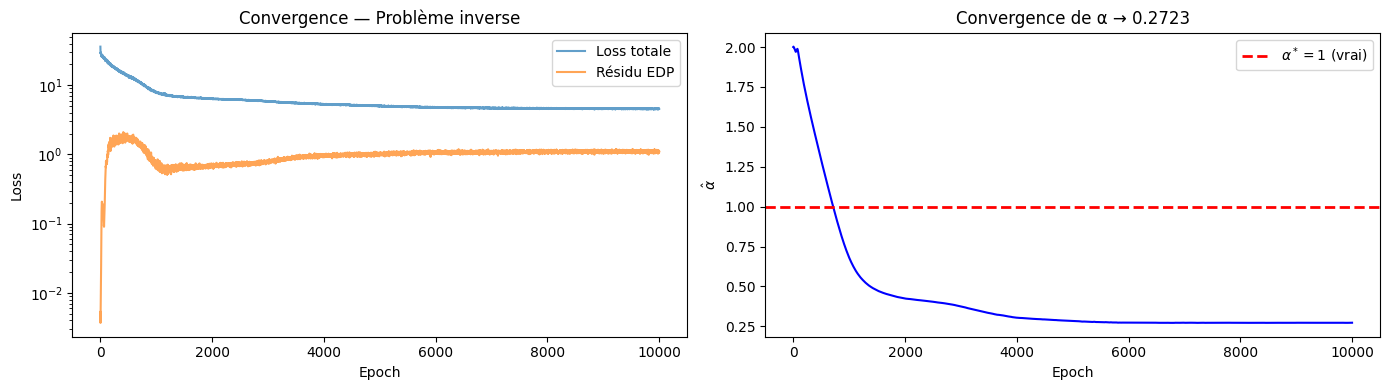

Résultat de l'inversion
α trouvé    : 0.2723 (cible : 1.0000)
m* trouvé   : 0.2460 mₑ (cible : 0.0670 mₑ)
m* trouvé   : 2.241e-31 kg (cible : 6.103e-32 kg)
Erreur rel. : 72.77%


In [ ]:
# --- Convergence de alpha ---
alpha_final = history_inv['alpha'][-1]
m_star_found = 0.067 / alpha_final  # en unités de m_e
m_star_found_kg = m_star_found * m_e

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(history_inv['loss'], label='Loss totale', alpha=0.7)
axes[0].semilogy(history_inv['loss_f'], label='Résidu EDP', alpha=0.7)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Convergence — Problème inverse')
axes[0].legend()

axes[1].plot(history_inv['alpha'], 'b-', linewidth=1.5)
axes[1].axhline(1.0, color='r', linestyle='--', linewidth=2, label=r'$\alpha^* = 1$ (vrai)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel(r'$\hat{\alpha}$')
axes[1].set_title(f'Convergence de α → {alpha_final:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"="*50)
print(f"Résultat de l'inversion")
print(f"="*50)
print(f"α trouvé    : {alpha_final:.4f} (cible : 1.0000)")
print(f"m* trouvé   : {m_star_found:.4f} mₑ (cible : 0.0670 mₑ)")
print(f"m* trouvé   : {m_star_found_kg:.3e} kg (cible : {m_star:.3e} kg)")
print(f"Erreur rel. : {abs(alpha_final - 1.0) / 1.0 * 100:.2f}%")

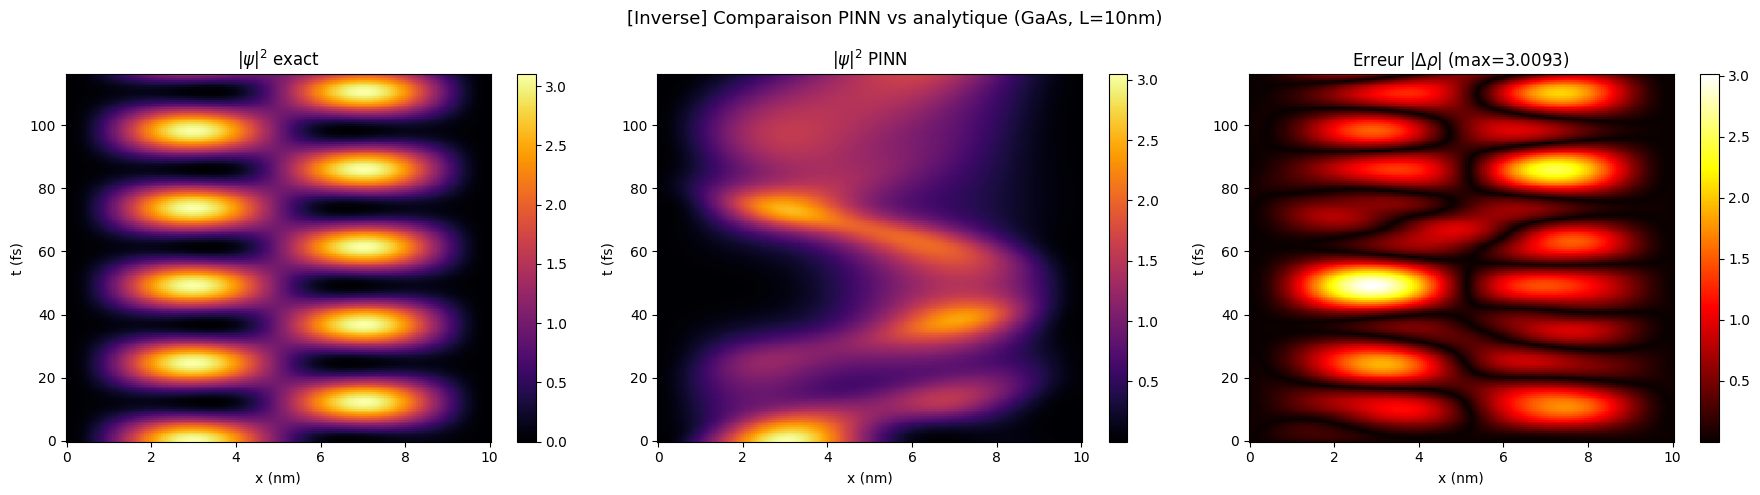

Erreur L² relative sur ψ : 1.3386e+00
Erreur moyenne sur |ψ|²  : 5.2640e-01


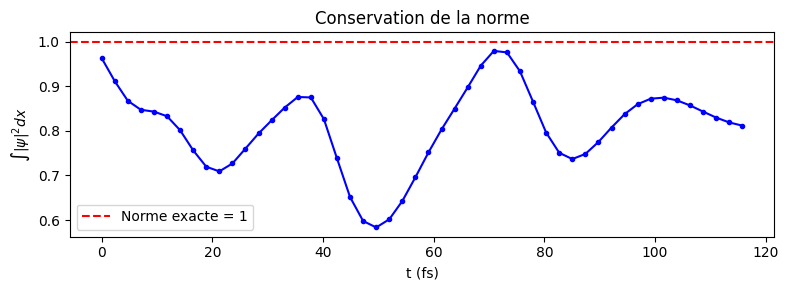

In [ ]:
# --- Comparaison PINN inverse vs analytique ---
err_inv = plot_comparison(net_inverse, T_max=T_MAX, title_prefix="[Inverse] ")

## 10. Étude de sensibilité du problème inverse

On fait varier le nombre de capteurs et le niveau de bruit pour observer la robustesse de l'inversion.

In [ ]:
# --- Étude : influence du nombre de capteurs ---
N_data_values = [20, 50, 100, 200, 500]
results_N = {}

for N_d in N_data_values:
    print(f"\n--- N_data = {N_d} ---")
    x_d = np.random.uniform(0.05, 0.95, N_d)
    t_d = np.random.uniform(0.05, T_MAX - 0.05, N_d)
    rho_d = np.abs(psi_exact(x_d, t_d))**2 + np.random.normal(0, 0.02, N_d)
    rho_d = np.clip(rho_d, 0, None)

    dp = {
        'x': torch.tensor(x_d, dtype=torch.float32, device=device).reshape(-1, 1),
        't': torch.tensor(t_d, dtype=torch.float32, device=device).reshape(-1, 1),
        'rho': torch.tensor(rho_d, dtype=torch.float32, device=device).reshape(-1, 1)
    }

    net_tmp = SchrodingerNet(hidden_dim=64, n_hidden=4).to(device)
    prob_tmp = SchrodingerProblem(net_tmp, alpha=2.0, alpha_trainable=True)
    hist_tmp = solve_schrodinger(prob_tmp, N_iter=6000, lr=1e-3, T_max=T_MAX,
                                  data_points=dp, lambda_data=10.0, verbose=False)
    alpha_found = hist_tmp['alpha'][-1]
    results_N[N_d] = {'alpha': alpha_found, 'history': hist_tmp['alpha']}
    print(f"  α trouvé = {alpha_found:.4f}, m* = {0.067/alpha_found:.4f} mₑ, erreur = {abs(alpha_found-1)*100:.2f}%")

# Graphe
fig, ax = plt.subplots(figsize=(8, 4))
for N_d, res in results_N.items():
    ax.plot(res['history'], label=f'N_data={N_d}', alpha=0.8)
ax.axhline(1.0, color='r', linestyle='--', linewidth=2, label=r'$\alpha^*=1$')
ax.set_xlabel('Epoch'); ax.set_ylabel(r'$\hat{\alpha}$')
ax.set_title('Influence du nombre de capteurs sur la convergence de α')
ax.legend()
plt.tight_layout()
plt.show()


--- N_data = 20 ---
  α trouvé = 0.7641, m* = 0.0877 mₑ, erreur = 23.59%

--- N_data = 50 ---
  α trouvé = 0.3368, m* = 0.1990 mₑ, erreur = 66.32%

--- N_data = 100 ---
  α trouvé = 0.1674, m* = 0.4002 mₑ, erreur = 83.26%

--- N_data = 200 ---
  α trouvé = 0.8713, m* = 0.0769 mₑ, erreur = 12.87%

--- N_data = 500 ---


KeyboardInterrupt: 

In [ ]:
# --- Étude : influence du bruit ---
sigma_values = [0.0, 0.01, 0.05, 0.1, 0.2]
results_sigma = {}

for sigma in sigma_values:
    print(f"\n--- σ_bruit = {sigma} ---")
    x_d = np.random.uniform(0.05, 0.95, 100)
    t_d = np.random.uniform(0.05, T_MAX - 0.05, 100)
    rho_d = np.abs(psi_exact(x_d, t_d))**2 + np.random.normal(0, sigma, 100)
    rho_d = np.clip(rho_d, 0, None)

    dp = {
        'x': torch.tensor(x_d, dtype=torch.float32, device=device).reshape(-1, 1),
        't': torch.tensor(t_d, dtype=torch.float32, device=device).reshape(-1, 1),
        'rho': torch.tensor(rho_d, dtype=torch.float32, device=device).reshape(-1, 1)
    }

    net_tmp = SchrodingerNet(hidden_dim=64, n_hidden=4).to(device)
    prob_tmp = SchrodingerProblem(net_tmp, alpha=2.0, alpha_trainable=True)
    hist_tmp = solve_schrodinger(prob_tmp, N_iter=6000, lr=1e-3, T_max=T_MAX,
                                  data_points=dp, lambda_data=10.0, verbose=False)
    alpha_found = hist_tmp['alpha'][-1]
    results_sigma[sigma] = {'alpha': alpha_found, 'history': hist_tmp['alpha']}
    print(f"  α trouvé = {alpha_found:.4f}, erreur = {abs(alpha_found-1)*100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
for sigma, res in results_sigma.items():
    ax.plot(res['history'], label=f'σ={sigma}', alpha=0.8)
ax.axhline(1.0, color='r', linestyle='--', linewidth=2, label=r'$\alpha^*=1$')
ax.set_xlabel('Epoch'); ax.set_ylabel(r'$\hat{\alpha}$')
ax.set_title('Influence du bruit sur la convergence de α')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Quantification d'incertitude — MC Dropout

On entraîne un PINN **avec dropout**, puis à l'inférence on garde le dropout actif et on fait $N$ passes forward pour estimer la variance prédictive (cf. cours, section 3).

In [ ]:
# --- Entraînement avec Dropout ---
net_dropout = SchrodingerNet(hidden_dim=64, n_hidden=4, dropout_rate=0.1).to(device)
problem_dropout = SchrodingerProblem(net_dropout, alpha=1.0, alpha_trainable=False)

print("Entraînement PINN avec dropout (p=0.1)...")
history_drop = solve_schrodinger(
    problem_dropout, N_iter=8000, lr=1e-3, T_max=T_MAX,
    lambda_ic=20.0, lambda_bc=20.0
)

In [ ]:
# --- MC Dropout : N passes à l'inférence ---
N_mc = 50
Nx_eval, Nt_eval = 100, 100

x_g = np.linspace(0, 1, Nx_eval)
t_g = np.linspace(0, T_MAX, Nt_eval)
X_eval, T_eval = np.meshgrid(x_g, t_g)
x_flat = torch.tensor(X_eval.ravel(), dtype=torch.float32, device=device).reshape(-1, 1)
t_flat = torch.tensor(T_eval.ravel(), dtype=torch.float32, device=device).reshape(-1, 1)

# Mode train pour garder le dropout actif
net_dropout.train()
rho_samples = []

for i in range(N_mc):
    with torch.no_grad():
        # En mode train, le dropout est actif → chaque passe donne un résultat différent
        out = net_dropout(x_flat, t_flat)
        u = out[:, 0].cpu().numpy()
        v = out[:, 1].cpu().numpy()
        rho_samples.append(u**2 + v**2)

rho_samples = np.array(rho_samples)  # (N_mc, N_points)
rho_mean = rho_samples.mean(axis=0).reshape(X_eval.shape)
rho_std = rho_samples.std(axis=0).reshape(X_eval.shape)

# Erreur réelle
rho_exact_eval = np.abs(psi_exact(X_eval, T_eval))**2
error_real = np.abs(rho_mean - rho_exact_eval)

# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].pcolormesh(X_eval * x_0_nm, T_eval * t_0_fs, rho_mean, cmap='inferno', shading='auto')
axes[0].set_title(r'$\overline{|\psi|^2}$ (moyenne MC Dropout)')
axes[0].set_xlabel('x (nm)'); axes[0].set_ylabel('t (fs)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(X_eval * x_0_nm, T_eval * t_0_fs, rho_std, cmap='YlOrRd', shading='auto')
axes[1].set_title(r'$\hat{\sigma}$ (incertitude MC Dropout)')
axes[1].set_xlabel('x (nm)'); axes[1].set_ylabel('t (fs)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(X_eval * x_0_nm, T_eval * t_0_fs, error_real, cmap='hot', shading='auto')
axes[2].set_title(r'Erreur réelle $|\overline{\rho} - \rho^*|$')
axes[2].set_xlabel('x (nm)'); axes[2].set_ylabel('t (fs)')
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f'MC Dropout ({N_mc} passes)', fontsize=13)
plt.tight_layout()
plt.show()

# Corrélation incertitude vs erreur
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(rho_std.ravel(), error_real.ravel(), s=1, alpha=0.3)
ax.set_xlabel(r'Incertitude estimée $\hat{\sigma}$')
ax.set_ylabel('Erreur réelle')
ax.set_title('Corrélation incertitude vs erreur (MC Dropout)')
ax.plot([0, rho_std.max()], [0, rho_std.max()], 'r--', label='y=x')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Quantification d'incertitude — Deep Ensembles

On entraîne $M=5$ PINNs avec des initialisations différentes, puis on combine leurs prédictions (cf. cours, section 3).

In [ ]:
# --- Entraînement de l'ensemble ---
M_ensemble = 5
ensemble_nets = []
ensemble_histories = []

for m in range(M_ensemble):
    print(f"\n{'='*40}")
    print(f"Entraînement membre {m+1}/{M_ensemble}")
    print(f"{'='*40}")
    torch.manual_seed(m * 123 + 7)  # seed différente pour chaque membre
    net_m = SchrodingerNet(hidden_dim=64, n_hidden=4).to(device)
    prob_m = SchrodingerProblem(net_m, alpha=1.0, alpha_trainable=False)
    hist_m = solve_schrodinger(
        prob_m, N_iter=6000, lr=1e-3, T_max=T_MAX,
        lambda_ic=20.0, lambda_bc=20.0, verbose=False
    )
    ensemble_nets.append(net_m)
    ensemble_histories.append(hist_m)
    print(f"  Loss finale : {hist_m['loss'][-1]:.2e}")

In [ ]:
# --- Prédictions de l'ensemble ---
rho_ensemble = []

for net_m in ensemble_nets:
    net_m.eval()
    with torch.no_grad():
        out = net_m(x_flat, t_flat)
        u = out[:, 0].cpu().numpy()
        v = out[:, 1].cpu().numpy()
        rho_ensemble.append(u**2 + v**2)

rho_ensemble = np.array(rho_ensemble)
rho_ens_mean = rho_ensemble.mean(axis=0).reshape(X_eval.shape)
rho_ens_std = rho_ensemble.std(axis=0).reshape(X_eval.shape)
error_ens = np.abs(rho_ens_mean - rho_exact_eval)

# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].pcolormesh(X_eval * x_0_nm, T_eval * t_0_fs, rho_ens_mean, cmap='inferno', shading='auto')
axes[0].set_title(r'$\overline{|\psi|^2}$ (moyenne ensemble)')
axes[0].set_xlabel('x (nm)'); axes[0].set_ylabel('t (fs)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(X_eval * x_0_nm, T_eval * t_0_fs, rho_ens_std, cmap='YlOrRd', shading='auto')
axes[1].set_title(r'$\hat{\sigma}$ (incertitude ensemble)')
axes[1].set_xlabel('x (nm)'); axes[1].set_ylabel('t (fs)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(X_eval * x_0_nm, T_eval * t_0_fs, error_ens, cmap='hot', shading='auto')
axes[2].set_title(r'Erreur réelle $|\overline{\rho} - \rho^*|$')
axes[2].set_xlabel('x (nm)'); axes[2].set_ylabel('t (fs)')
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f'Deep Ensembles (M={M_ensemble})', fontsize=13)
plt.tight_layout()
plt.show()

# Corrélation
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(rho_ens_std.ravel(), error_ens.ravel(), s=1, alpha=0.3, color='green')
ax.set_xlabel(r'Incertitude estimée $\hat{\sigma}$')
ax.set_ylabel('Erreur réelle')
ax.set_title('Corrélation incertitude vs erreur (Deep Ensembles)')
ax.plot([0, rho_ens_std.max()], [0, rho_ens_std.max()], 'r--', label='y=x')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Incertitude sur le problème inverse (barre d'erreur sur $m^*$)

On entraîne un ensemble de PINNs en mode inverse pour obtenir une distribution de $\hat{\alpha}$, ce qui donne directement une barre d'erreur sur $m^*$.

In [ ]:
# --- Ensemble pour le problème inverse ---
M_inv = 5
alpha_estimates = []

for m in range(M_inv):
    print(f"\nMembre inverse {m+1}/{M_inv}")
    torch.manual_seed(m * 456 + 13)
    net_m = SchrodingerNet(hidden_dim=64, n_hidden=4).to(device)
    prob_m = SchrodingerProblem(net_m, alpha=2.0, alpha_trainable=True)
    hist_m = solve_schrodinger(
        prob_m, N_iter=8000, lr=1e-3, T_max=T_MAX,
        lambda_ic=20.0, lambda_bc=20.0,
        data_points=data_points, lambda_data=10.0, verbose=False
    )
    alpha_found = hist_m['alpha'][-1]
    alpha_estimates.append(alpha_found)
    print(f"  α = {alpha_found:.4f} → m* = {0.067/alpha_found:.4f} mₑ")

alpha_arr = np.array(alpha_estimates)
m_star_arr = 0.067 / alpha_arr

print(f"\n{'='*50}")
print(f"RÉSULTAT FINAL (ensemble de {M_inv} PINNs)")
print(f"{'='*50}")
print(f"α = {alpha_arr.mean():.4f} ± {alpha_arr.std():.4f}")
print(f"m* = ({m_star_arr.mean():.4f} ± {m_star_arr.std():.4f}) mₑ")
print(f"m* = ({m_star_arr.mean()*m_e:.3e} ± {m_star_arr.std()*m_e:.3e}) kg")
print(f"\nValeur cible : m* = 0.0670 mₑ = {0.067*m_e:.3e} kg")
print(f"Erreur relative : {abs(m_star_arr.mean() - 0.067)/0.067*100:.2f}%")

# Graphe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, M_inv+1), alpha_arr, color='steelblue', alpha=0.8)
axes[0].axhline(1.0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Membre de l\'ensemble')
axes[0].set_ylabel(r'$\hat{\alpha}$')
axes[0].set_title(r'Estimations de $\alpha$ par Deep Ensembles')

axes[1].bar(range(1, M_inv+1), m_star_arr*1000, color='darkorange', alpha=0.8)
axes[1].axhline(67, color='r', linestyle='--', linewidth=2, label='$m^*_{vrai}$')
axes[1].errorbar(3, m_star_arr.mean()*1000, yerr=m_star_arr.std()*1000,
                  fmt='ko', capsize=5, markersize=8, label='Moyenne ± σ')
axes[1].set_xlabel('Membre de l\'ensemble')
axes[1].set_ylabel(r'$m^*$ ($10^{-3}\,m_e$)')
axes[1].set_title(r'Estimation de $m^*$ avec barre d\'erreur')
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Diagramme de calibration

Pour évaluer la qualité de l'incertitude (cf. cours, ECE), on vérifie que les intervalles de confiance $\hat{\psi} \pm k\hat{\sigma}$ couvrent bien la bonne fraction de la vérité terrain.

In [ ]:
def calibration_curve(rho_mean_flat, rho_std_flat, rho_exact_flat, n_bins=10):
    """Calcule le diagramme de calibration pour la régression."""
    confidence_levels = np.linspace(0.05, 0.95, n_bins)
    observed_coverage = []
    
    for p in confidence_levels:
        # Intervalle de confiance à p : ±z*sigma
        from scipy.stats import norm
        z = norm.ppf(0.5 + p/2)
        lower = rho_mean_flat - z * rho_std_flat
        upper = rho_mean_flat + z * rho_std_flat
        covered = np.mean((rho_exact_flat >= lower) & (rho_exact_flat <= upper))
        observed_coverage.append(covered)
    
    return confidence_levels, np.array(observed_coverage)

# --- Calibration MC Dropout ---
conf_levels, coverage_mc = calibration_curve(
    rho_mean.ravel(), rho_std.ravel(), rho_exact_eval.ravel()
)

# --- Calibration Deep Ensembles ---
_, coverage_ens = calibration_curve(
    rho_ens_mean.ravel(), rho_ens_std.ravel(), rho_exact_eval.ravel()
)

# ECE
ece_mc = np.mean(np.abs(coverage_mc - conf_levels))
ece_ens = np.mean(np.abs(coverage_ens - conf_levels))

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
ax.plot(conf_levels, coverage_mc, 'bo-', label=f'MC Dropout (ECE={ece_mc:.3f})')
ax.plot(conf_levels, coverage_ens, 'g^-', label=f'Deep Ensembles (ECE={ece_ens:.3f})')
ax.set_xlabel('Niveau de confiance attendu')
ax.set_ylabel('Couverture observée')
ax.set_title('Diagramme de calibration')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"ECE MC Dropout     : {ece_mc:.4f}")
print(f"ECE Deep Ensembles : {ece_ens:.4f}")

## 15. Comportement en extrapolation temporelle

On teste le PINN au-delà du domaine d'entraînement ($t > T_{max}$). L'incertitude doit fortement augmenter.

In [ ]:
# --- Extrapolation : évaluer sur [0, 2*T_MAX] ---
T_extrap = 2 * T_MAX
X_ext, T_ext, u_ext, v_ext = evaluate_pinn(net_forward, Nx=100, Nt=200, T_max=T_extrap)
rho_ext = u_ext**2 + v_ext**2
rho_exact_ext = np.abs(psi_exact(X_ext, T_ext))**2
error_ext = np.abs(rho_ext - rho_exact_ext)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].pcolormesh(X_ext * x_0_nm, T_ext * t_0_fs, rho_exact_ext, cmap='inferno', shading='auto')
axes[0].axhline(T_MAX * t_0_fs, color='lime', linestyle='--', linewidth=2, label='Fin entraînement')
axes[0].set_title(r'$|\psi|^2$ exact'); axes[0].set_xlabel('x (nm)'); axes[0].set_ylabel('t (fs)')
axes[0].legend(); plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(X_ext * x_0_nm, T_ext * t_0_fs, rho_ext, cmap='inferno', shading='auto')
axes[1].axhline(T_MAX * t_0_fs, color='lime', linestyle='--', linewidth=2, label='Fin entraînement')
axes[1].set_title(r'$|\psi|^2$ PINN'); axes[1].set_xlabel('x (nm)'); axes[1].set_ylabel('t (fs)')
axes[1].legend(); plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(X_ext * x_0_nm, T_ext * t_0_fs, error_ext, cmap='hot', shading='auto')
axes[2].axhline(T_MAX * t_0_fs, color='lime', linestyle='--', linewidth=2, label='Fin entraînement')
axes[2].set_title('Erreur (noter la zone d\'extrapolation)'); axes[2].set_xlabel('x (nm)'); axes[2].set_ylabel('t (fs)')
axes[2].legend(); plt.colorbar(im2, ax=axes[2])

plt.suptitle(f'Extrapolation temporelle : entraîné sur [0, {T_MAX*t_0_fs:.0f}] fs, évalué sur [0, {T_extrap*t_0_fs:.0f}] fs', fontsize=13)
plt.tight_layout()
plt.show()

# Erreur moyenne par tranche de temps
t_slices = np.linspace(0, T_extrap, 200)
err_by_t = []
for i, tv in enumerate(t_slices):
    err_slice = np.mean(error_ext[i, :])
    err_by_t.append(err_slice)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_slices * t_0_fs, err_by_t, 'b-')
ax.axvline(T_MAX * t_0_fs, color='r', linestyle='--', linewidth=2, label='Fin entraînement')
ax.set_xlabel('t (fs)')
ax.set_ylabel(r'Erreur moyenne $|\Delta\rho|$')
ax.set_title('Erreur en fonction du temps : dégradation en extrapolation')
ax.legend()
plt.tight_layout()
plt.show()

## Résumé

| Composant | TP Chaleur | Ce projet |
|-----------|-----------|-----------|
| Système | Barre conductrice | Puits quantique GaAs (10 nm) |
| EDP | $c\,\partial_t u = \partial_x(k\partial_x u) + q - \beta u$ | $i\partial_t\psi = -\frac{\alpha}{2}\partial_{xx}\psi$ |
| Sortie réseau | $u \in \mathbb{R}$ | $(u,v) \in \mathbb{R}^2$ |
| Paramètre inversé | conductivité $k(x)$ | masse effective $m^*$ via $\alpha$ |
| Données capteurs | température | densité $|\psi|^2$ |
| Vérité terrain | solution numérique | **solution analytique exacte** |
| Grandeurs | m, s, K | nm, fs, meV |